In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import fsolve

In [81]:
# Parameters

ticker = yf.Ticker("MSFT")                          # Microsoft
S0 = ticker.history(period="1d")["Close"].iloc[-1]  # spot price in $
sigma0 = 0.6
r= 0.03         # interest rate
q = 0           # dividend yield
print(S0)

493.7799987792969


In [82]:
expiries = ticker.options  # available maturity
expiries
expiries = list(expiries)
expiries

['2026-09-21',
 '2026-09-23',
 '2026-09-25',
 '2026-09-28',
 '2026-09-30',
 '2026-10-02',
 '2026-10-09',
 '2026-10-16',
 '2026-10-23',
 '2026-10-30',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-03-19',
 '2027-04-16',
 '2027-06-17',
 '2027-09-17',
 '2027-12-17',
 '2028-01-21',
 '2028-06-16',
 '2028-12-15',
 '2029-01-19']

In [83]:
# for each maturity date, we add a price, strike for a call option and put option

L_call = []
L_put = []

for maturity in expiries:

    option_chain = ticker.option_chain(date=maturity)

    call = option_chain.calls
    call["Maturity"] = maturity
    L_call.append(call)

    put = option_chain.puts
    put["Maturity"] = maturity
    L_put.append(put)

df_call= pd.concat(L_call)
df_put = pd.concat(L_put)
df_call


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Maturity
0,MSFT260921C00430000,2026-09-18 19:42:05+00:00,430.0,64.60,62.40,65.30,2.299999,3.691813,2.0,5.0,0.775393,True,REGULAR,USD,2026-09-21
1,MSFT260921C00435000,2026-09-18 18:52:33+00:00,435.0,61.54,57.40,60.15,1.790001,2.995817,3.0,6.0,1.189457,True,REGULAR,USD,2026-09-21
2,MSFT260921C00440000,2026-09-18 18:11:14+00:00,440.0,54.65,52.55,55.10,-6.500000,-10.629599,4.0,1.0,0.625004,True,REGULAR,USD,2026-09-21
3,MSFT260921C00450000,2026-09-18 19:58:57+00:00,450.0,43.63,42.65,44.70,-0.040001,-0.091598,16.0,0.0,0.850099,True,REGULAR,USD,2026-09-21
4,MSFT260921C00455000,2026-09-11 17:27:13+00:00,455.0,41.28,37.45,40.30,0.000000,0.000000,NaN,1.0,0.508794,True,REGULAR,USD,2026-09-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,MSFT290119C00710000,2026-09-18 13:42:13+00:00,710.0,51.00,48.00,52.00,-1.259998,-2.411019,1.0,4.0,0.371382,False,REGULAR,USD,2029-01-19
41,MSFT290119C00720000,2026-09-16 13:47:41+00:00,720.0,48.96,46.00,49.45,0.000000,0.000000,NaN,4.0,0.368514,False,REGULAR,USD,2029-01-19
42,MSFT290119C00730000,2026-09-18 13:46:18+00:00,730.0,47.69,44.00,47.50,0.000000,0.000000,1.0,0.0,0.367530,False,REGULAR,USD,2029-01-19
43,MSFT290119C00740000,2026-09-16 16:48:50+00:00,740.0,45.51,42.50,46.35,0.000000,0.000000,NaN,0.0,0.369223,False,REGULAR,USD,2029-01-19


In [84]:
columns = ["strike",'Maturity',"lastPrice","bid","ask","impliedVolatility","volume"]



df_call = df_call[columns]

df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])

df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])

# filter

# Strike between 80% et 120%
strike_filter = (S0*0.8< df_call["strike"]) & (df_call["strike"]<S0*1.2)
df_call = df_call[strike_filter]

# maturity between today and 3 months 
maturity_filter = (df_call["Maturity"]>pd.Timestamp.today()) & (df_call["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_call = df_call[maturity_filter]

# volume > 50
df_call = df_call[df_call["volume"]>50]

# mid 
mid_filter = (df_call["mid"] >= 0.10)
df_call = df_call[mid_filter]

df_call

# Put filter

df_put = df_put[columns]
df_put["mid"] = 0.5 * (df_put["bid"] + df_put["ask"])
df_put["Maturity"] = pd.to_datetime(df_put["Maturity"])



strike_filter = (S0*0.8< df_put["strike"]) & (df_put["strike"]<S0*1.2)
df_put = df_put[strike_filter]

maturity_filter = (df_put["Maturity"]>pd.Timestamp.today()) & (df_put["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_put = df_put[maturity_filter]

# volume > 50
df_put = df_put[df_put["volume"]>50]

# mid 
mid_filter = (df_put["mid"] >= 0.10)
df_put = df_put[mid_filter]

df_call


C:\Users\antoi\AppData\Local\Temp\ipykernel_2012\55049844.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])
C:\Users\antoi\AppData\Local\Temp\ipykernel_2012\55049844.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])


,strike,Maturity,lastPrice,bid,ask,impliedVolatility,volume,mid
15,487.5,2026-09-23,9.03,7.95,9.70,0.295173,116.0,8.825
16,490.0,2026-09-23,6.61,6.65,7.65,0.270515,94.0,7.150
17,492.5,2026-09-23,5.80,5.20,6.10,0.263923,316.0,5.650
18,495.0,2026-09-23,4.22,3.95,4.50,0.246345,928.0,4.225
19,497.5,2026-09-23,3.15,2.47,3.35,0.241096,349.0,2.910
...,...,...,...,...,...,...,...,...
74,545.0,2026-12-18,11.91,10.95,12.25,0.306129,222.0,11.600
75,550.0,2026-12-18,10.50,9.85,11.05,0.305183,273.0,10.450
79,570.0,2026-12-18,6.90,6.30,7.35,0.304603,332.0,6.825
80,575.0,2026-12-18,5.80,5.75,6.50,0.302741,238.0,6.125


In [85]:
# Price Call/Put with Black and Scholes
def black_scholes(S0,K,r,sigma,T,q,option_type="call"):

    d1= (np.log(S0/K)+(0.5*sigma**2*+r-q)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2) 
    
    if option_type == "put":
        return K*np.exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1) 

In [86]:
option_type = "call"

In [87]:
# Function to get the determine the implied volatility
def implied_volatility(S0,K,T,r,q,market_price):
    def f(sigma):
        return black_scholes(S0,K,r,sigma,T,q,option_type)-market_price
    return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)  

In [88]:
# For every maturity date, we want to know the value of the implied volatility for each strike

smile = {}

for t in df_call["Maturity"].drop_duplicates():
    time_to_maturity = (t - pd.Timestamp.today()).days / 365
    L_implied_vol=[]
    L_K = []

    df_t = df_call[df_call["Maturity"]==t]

    for _,row in df_t.iterrows():
        K = row["strike"]
        market_price = row["mid"]  #row["lastPrice"]

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])
        L_implied_vol.append(implied_vol)
        L_K.append(K)
    
    smile[t] = {"K":L_K,
                "iv":L_implied_vol}
        

In [89]:
smile

{Timestamp('2026-09-23 00:00:00'): {'K': [487.5,
   490.0,
   492.5,
   495.0,
   497.5,
   500.0,
   502.5,
   505.0,
   507.5,
   510.0,
   512.5,
   515.0,
   520.0],
  'iv': [0.49282058814661805,
   0.48783690477082514,
   0.48193581195969587,
   0.4642202230845684,
   0.43612130985733194,
   0.45609457997567465,
   0.46305412542786173,
   0.4610896445062734,
   0.45884977129230625,
   0.48226064601693225,
   0.5288570361695284,
   0.49003101442886793,
   0.5293380398032127]},
 Timestamp('2026-09-25 00:00:00'): {'K': [442.5,
   475.0,
   480.0,
   485.0,
   487.5,
   490.0,
   492.5,
   495.0,
   497.5,
   500.0,
   502.5,
   505.0,
   507.5,
   510.0,
   512.5,
   515.0,
   517.5,
   520.0,
   522.5,
   525.0,
   530.0,
   532.5],
  'iv': [0.6426698309083501,
   0.39652248474988083,
   0.3789921224905009,
   0.3427875296730883,
   0.35147176535100766,
   0.3402448315073836,
   0.34207983770227224,
   0.34315452105043526,
   0.3407515781362282,
   0.3527860715418453,
   0.336362046

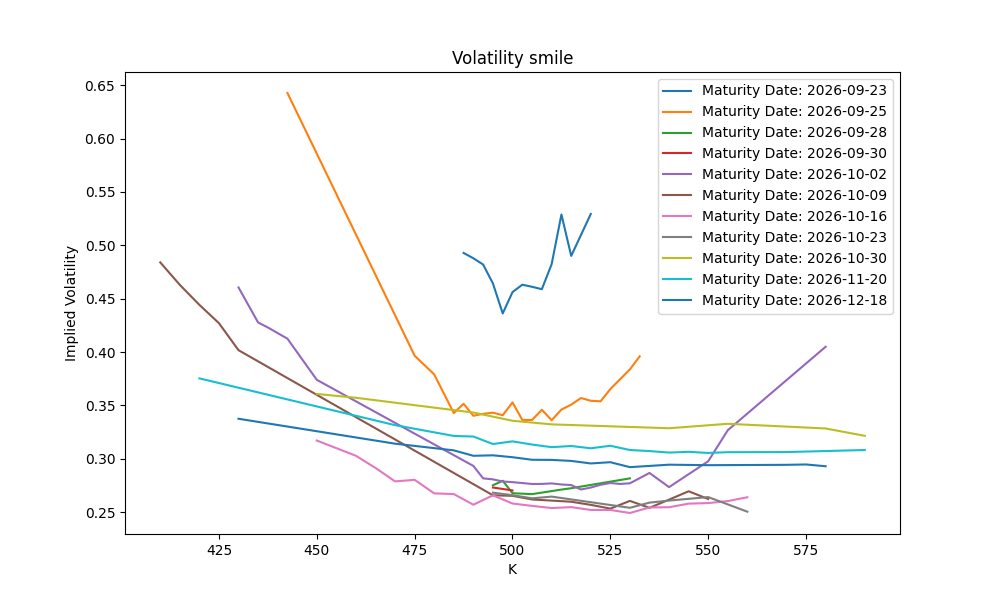

In [90]:
plt.figure(figsize=(10,6))
for t, data in smile.items():  # smile.items() renvoie couples (clé,valeur)
    plt.plot(data["K"],data["iv"],label="Maturity Date: " + str(t.date()))

plt.xlabel("K")
plt.ylabel("Implied Volatility")
plt.title('Volatility smile')
plt.legend()
plt.show()

In [91]:
term_structure = {}
df_call = df_call.sort_values(by="strike",ascending=True)
for K in df_call["strike"].drop_duplicates():
    L_implied_vol=[]
    L_T = []

    df_K = df_call[df_call["strike"]==K]

    for _,row in df_K.iterrows():
        T = row["Maturity"]
        time_to_maturity = (T - pd.Timestamp.today()).days / 365
        market_price = row["mid"] # row["lastPrice"]

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])  # [0]
        
        L_implied_vol.append(implied_vol)
        #implied_vol = row["impliedVolatility"]
        L_T.append(T)
    
    term_structure[K] = {"T":L_T,
                "iv":L_implied_vol}
print(term_structure)

{410.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.48398614624963143]}, 415.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.46294233725963024]}, 420.0: {'T': [Timestamp('2026-10-09 00:00:00'), Timestamp('2026-11-20 00:00:00')], 'iv': [0.44418880331525856, 0.37530297791127304]}, 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.4270130282297161]}, 430.0: {'T': [Timestamp('2026-10-02 00:00:00'), Timestamp('2026-12-18 00:00:00'), Timestamp('2026-10-09 00:00:00')], 'iv': [0.46049988704578165, 0.33745284768444495, 0.40170538289909946]}, 435.0: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.4276689254290201]}, 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.4229731041002934]}, 442.5: {'T': [Timestamp('2026-10-02 00:00:00'), Timestamp('2026-09-25 00:00:00')], 'iv': [0.41247896658846667, 0.6426698309083501]}, 450.0: {'T': [Timestamp('2026-10-02 00:00:00'), Timestamp('2026-10-30 00:00:00'), Timestamp('2026-10-16 00:00:00')], 'iv': [0.37394342058317526, 0.3607

In [92]:
term_structure

{410.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.48398614624963143]},
 415.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.46294233725963024]},
 420.0: {'T': [Timestamp('2026-10-09 00:00:00'),
   Timestamp('2026-11-20 00:00:00')],
  'iv': [0.44418880331525856, 0.37530297791127304]},
 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.4270130282297161]},
 430.0: {'T': [Timestamp('2026-10-02 00:00:00'),
   Timestamp('2026-12-18 00:00:00'),
   Timestamp('2026-10-09 00:00:00')],
  'iv': [0.46049988704578165, 0.33745284768444495, 0.40170538289909946]},
 435.0: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.4276689254290201]},
 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.4229731041002934]},
 442.5: {'T': [Timestamp('2026-10-02 00:00:00'),
   Timestamp('2026-09-25 00:00:00')],
  'iv': [0.41247896658846667, 0.6426698309083501]},
 450.0: {'T': [Timestamp('2026-10-02 00:00:00'),
   Timestamp('2026-10-30 00:00:00'),
   Timestamp('2026-10-16 00:00:00')],
  

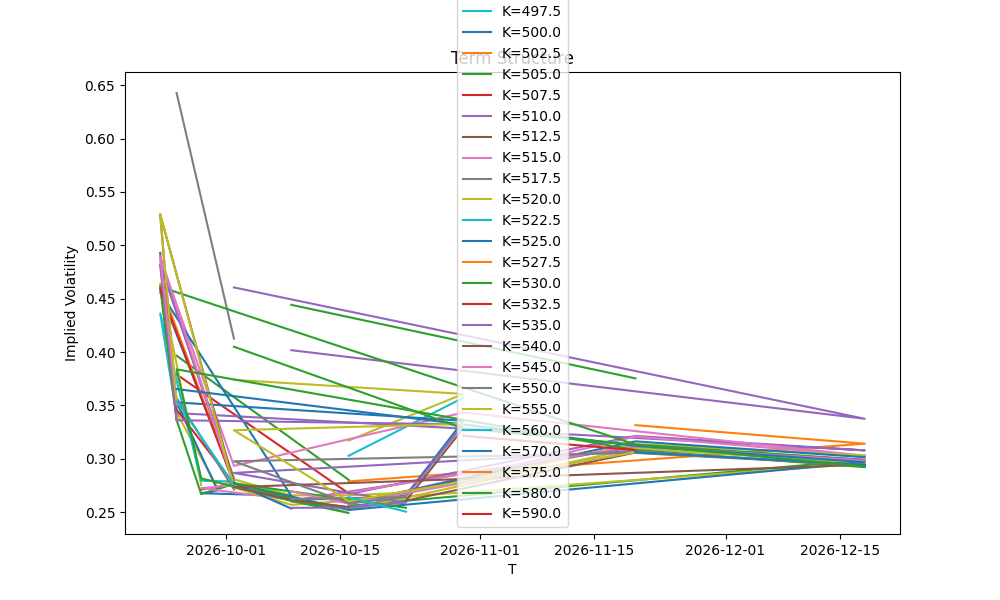

In [97]:
plt.figure(figsize=(10,6))
Ks_to_plot = np.arange(360,450,10) #[360.0, 370 ,380.0,390,400,410]
for K, data in term_structure.items():  # smile.items() renvoie couples (clé,valeur)
    #print(data)
    #if K not in Ks_to_plot:
        #continue
    plt.plot(data["T"],data["iv"],label=f"K={K}")

plt.xlabel("T")
plt.ylabel("Implied Volatility")
plt.title('Term Structure')
plt.legend()
plt.show()